# Outfit Compatiblity Rater


#### Imports

In [25]:
# %pip install -r requirements.txt

In [26]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import seaborn as sns

#### Load Data Files

In [27]:
# Compatibility labels
with open('polyvore/fashion_compatibility_prediction.txt', 'r') as f:
    lines = f.readlines()
    
# Load and combine JSON files
with open('polyvore/train_no_dup.json', 'r') as f:
    train_data = json.load(f)
with open('polyvore/test_no_dup.json', 'r') as f:
    test_data = json.load(f)
with open('polyvore/valid_no_dup.json', 'r') as f:
    valid_data = json.load(f)

all_outfits = train_data + test_data + valid_data

#### Build Lookup Tables

In [28]:
# Image lookup 
image_lookup = {}
for category in os.listdir('images/Re-PolyVore'):
    category_path = f'images/Re-PolyVore/{category}'
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.endswith('.jpg'):
                item_id = filename.replace('.jpg', '')
                image_lookup[item_id] = f'{category_path}/{filename}'

# Name lookup
name_lookup = {}
for outfit in all_outfits:
    set_id = outfit['set_id']
    for item in outfit['items']:
        item_id = f"{set_id}_{item['index']}"
        name_lookup[item_id] = item['name']

#### Visualize Example Outfit

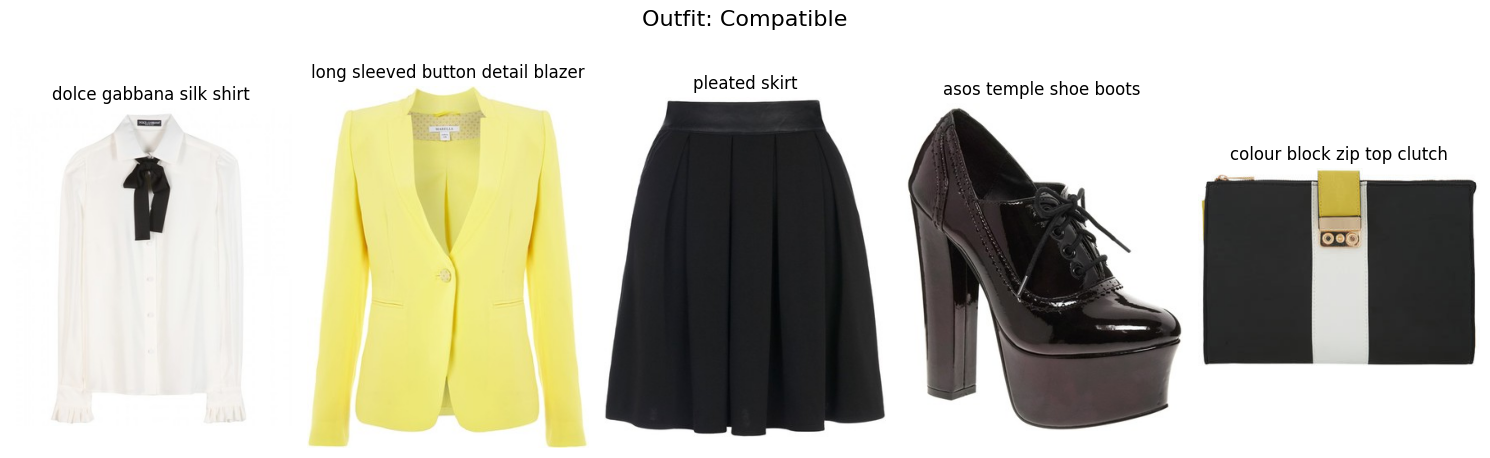

In [29]:
first_outfit = lines[0].strip().split()
label = first_outfit[0]
items = first_outfit[1:]

fig, axes = plt.subplots(1, len(items), figsize=(15, 5))

for i, item_id in enumerate(items):
    if item_id in image_lookup:
        img = Image.open(image_lookup[item_id])
        axes[i].imshow(img)
        name = name_lookup.get(item_id, 'Unknown')
        axes[i].set_title(name, fontsize=12, wrap=True)
        axes[i].axis('off')
    else:
        print(f"Missing: {item_id}")

label_text = "Compatible" if label == '1' else "Incompatible"
plt.suptitle(f"Outfit: {label_text}", fontsize=16)
plt.tight_layout()
plt.show()

#### Preprocessing (ResNet50 Embeddings)

In [30]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
base_model.trainable = False

In [31]:
# Embedding functions

def get_item_embedding(item_id):
    """
    Converts a single clothing item image into a numerical representation
    using the pretrained ResNet50 model.
        
    Parameters:
        item_id (str): The unique identifier for the clothing item, such as: 
            '119704139_1'
    Returns:
        numpy array of shape (2048,): A vector of 2048 numbers that 
            describes the visual features of the clothing item such as
            color, texture, and style.
    """
    img_path = image_lookup[item_id]
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    embedding = base_model.predict(img_array, verbose=0)
    return embedding[0]


def get_average_outfit_embedding(item_ids):
    """
    This function is used for Model A: Average Embedding Classifier.

    Converts a full outfit into a single average embedding representation.
    Instead of preserving each clothing item separately, it averages all
    available item embeddings into one 2048-dimensional vector, creating
    a general representation of the outfit's overall visual style.

    Parameters:
        item_ids (list): A list of item ID strings for one outfit, such as:
            ['119704139_1', '119704139_2', '119704139_3']
    Returns:
        numpy array of shape (2048,):
            The average ResNet50 embedding across all available item images
            in the outfit.
        None:
            Returned if none of the outfit's item images are found in
            image_lookup.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id))
    if not embeddings:
        return None
    return np.mean(embeddings, axis=0)


def get_outfit_embedding(item_ids, max_items=4):
    """
    This function is used for Model B: Concatenation + Average Embedding Classifier. 

    Converts a full outfit (with up to four clothing items) into a single 
    numerical representation. 

    Parameters:
        item_ids (list): List of item ID strings for this outfit
        max_items (int): Fixed number of items to pad/cut to (default 4)
    Returns:
        numpy array of shape (10240,): Fixed-size outfit representation
            (4 items x 2048 numbers + 2048 mean numbers)
        Returns None if no images found for this outfit.
    """
    embeddings = []
    for item_id in item_ids:
        if item_id in image_lookup:
            embeddings.append(get_item_embedding(item_id)) 
    if not embeddings:
        return None
    dimension = embeddings[0].shape[0]
    mean_emb = np.mean(embeddings, axis=0)
    while len(embeddings) < max_items:
        embeddings.append(np.zeros(dimension))
    embeddings = embeddings[:max_items]
    
    return np.concatenate(embeddings + [mean_emb])

#### Model A: Average Embedding Classifier

In [32]:
# # Only run this cell if the saved average embedding files are missing.

# X_avg = []
# y_avg = []
# skipped_avg = 0

# for i, line in enumerate(lines):
#     parts = line.strip().split()
    
#     if len(parts) < 2:
#         skipped_avg += 1
#         continue
    
#     label = int(parts[0])
#     item_ids = parts[1:]
    
#     outfit_vec = get_average_outfit_embedding(item_ids)
    
#     if outfit_vec is not None:
#         X_avg.append(outfit_vec)
#         y_avg.append(label)
#     else:
#         skipped_avg += 1
    
#     if i % 500 == 0:
#         print(f"Processed {i}/{len(lines)} outfits for Model A average embeddings...")

# X_avg = np.array(X_avg)
# y_avg = np.array(y_avg)

# print("Done generating Model A average embeddings!")
# print(f"Skipped: {skipped_avg}")
# print(f"X_avg shape: {X_avg.shape}")
# print(f"y_avg shape: {y_avg.shape}")

# np.save("X_avg_embeddings.npy", X_avg)
# np.save("y_avg_labels.npy", y_avg)

In [33]:
# Model A: Load Saved Average Embeddings
X_avg = np.load("X_avg_embeddings.npy")
y_avg = np.load("y_avg_labels.npy")

In [34]:
# Model A: Train/Test Split
X_avg_train, X_avg_test, y_avg_train, y_avg_test = train_test_split(
    X_avg, y_avg, test_size=0.2, random_state=42, stratify=y_avg
)

In [35]:
# Model A: Average Embedding Classifier

input_dim_avg = X_avg_train.shape[1]

model_avg = Sequential([
    Dense(512, input_shape=(input_dim_avg,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_avg.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,025 (4.64 MB)

 Trainable params: 1,215,233 (4.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [36]:
# Compile Model A

model_avg.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [37]:
# Model A: Early stopping and learning rate reduction

early_stop_avg = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr_avg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [38]:
# Train Model A

history_avg = model_avg.fit(
    X_avg_train,
    y_avg_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop_avg, reduce_lr_avg]
)

Epoch 1/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5184 - loss: 0.8696 - val_accuracy: 0.5560 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 2/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5626 - loss: 0.7558 - val_accuracy: 0.5942 - val_loss: 0.7337 - learning_rate: 0.0010
Epoch 3/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5779 - loss: 0.7199 - val_accuracy: 0.5560 - val_loss: 0.7041 - learning_rate: 0.0010
Epoch 4/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6077 - loss: 0.6869 - val_accuracy: 0.5995 - val_loss: 0.6859 - learning_rate: 0.0010
Epoch 5/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6251 - loss: 0.6704 - val_accuracy: 0.6113 - val_loss: 0.6794 - learning_rate: 0.0010
Epoch 6/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6467 - loss: 0.6419 - val_accuracy: 0.6008 - val_loss: 0.6857 - learning_rate: 0.0010
Epoch 7/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6600 - loss: 0.6244 - val_accuracy: 

In [39]:
# Evaluate Model A
avg_result = model_avg.evaluate(X_avg_test, y_avg_test, verbose=0)
print(f"Model A Final Test Accuracy: {avg_result[1] * 100:.2f}%")

Model A Final Test Accuracy: 61.66%


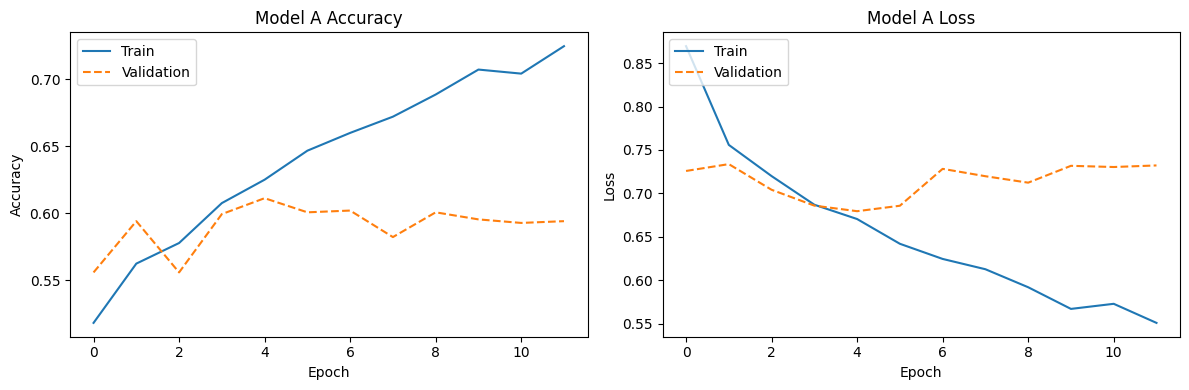

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


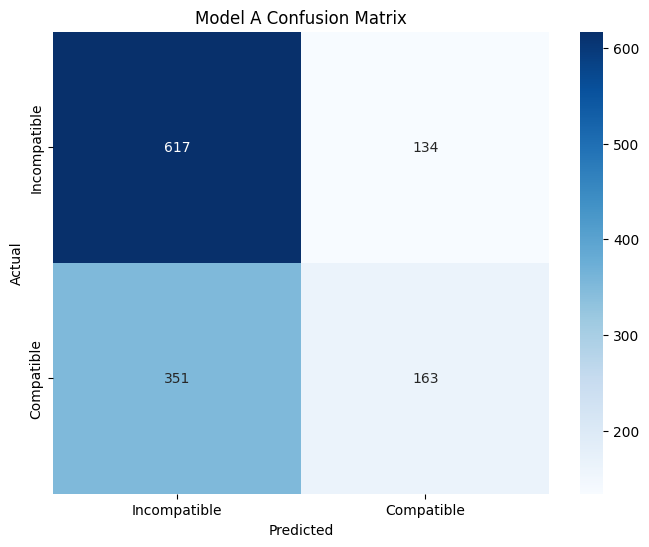

In [40]:
# Accuracy and Loss Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_avg.history['accuracy'], label='Train')
plt.plot(history_avg.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model A Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_avg.history['loss'], label='Train')
plt.plot(history_avg.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model A Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Confusion Matrix
y_avg_pred = (model_avg.predict(X_avg_test) > 0.5).astype(int)

cm_avg = confusion_matrix(y_avg_test, y_avg_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_avg,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)

plt.title('Model A Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### Model B: Concatenation + Average Embedding Classifier

In [41]:
# # Only run this cell if the saved concatenation + average embedding files are missing.

# X = []
# y = []
# skipped = 0

# for i, line in enumerate(lines):
#     parts = line.strip().split()
#     if len(parts) < 2:     
#         skipped += 1
#         continue
    
#     label = int(parts[0])
#     item_ids = parts[1:]
    
#     outfit_vec = get_outfit_embedding(item_ids)
    
#     if outfit_vec is not None:
#         X.append(outfit_vec)
#         y.append(label)
#     else:
#         skipped += 1
    
#     if i % 500 == 0:
#         print(f"Processed {i}/{len(lines)} outfits...")

# X = np.array(X)
# y = np.array(y)

# print(f"Done! Skipped: {skipped}")
# print(f"X shape: {X.shape}")
# print(f"Compatible: {sum(y==1)}, Incompatible: {sum(y==0)}")

# np.save('X_outfit_embeddings.npy', X)
# np.save('y_labels.npy', y)
# print("Embeddings saved!")

In [42]:
# Model B: Load Saved Embeddings
X = np.load('X_outfit_embeddings.npy')
y = np.load('y_labels.npy')

In [43]:
# Model B: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
# Model B: Concatenation + Average Embedding Classifier
input_dim = X_train.shape[1]

model = Sequential([
    Dense(1024, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.summary()

/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/envs/ann_final_project/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1024)           │    10,486,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,183,617 (42.66 MB)

 Trainable params: 11,179,777 (42.65 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [45]:
# Compile Model B
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'] 
)

In [46]:
# Added early_stop to prevent overfitting by stopping when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

# Added reduce_lr to reduce learning rate when training gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Train Model B
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.6214 - loss: 0.7308 - val_accuracy: 0.6337 - val_loss: 0.8144 - learning_rate: 0.0010
Epoch 2/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6863 - loss: 0.6132 - val_accuracy: 0.6877 - val_loss: 0.6394 - learning_rate: 0.0010
Epoch 3/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7116 - loss: 0.5599 - val_accuracy: 0.6943 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 4/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7493 - loss: 0.5189 - val_accuracy: 0.6245 - val_loss: 0.7114 - learning_rate: 0.0010
Epoch 5/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7681 - loss: 0.4781 - val_accuracy: 0.6627 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 6/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7909 - loss: 0.4425 - val_accuracy: 0.6746 - val_loss: 0.8138 - learning_rate: 0.0010
Epoch 7/60
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8319 - loss: 0.3608 - val_acc

In [47]:
# Evaluate Model B
result = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {result[1]*100:.2f}%")

Final Test Accuracy: 69.72%


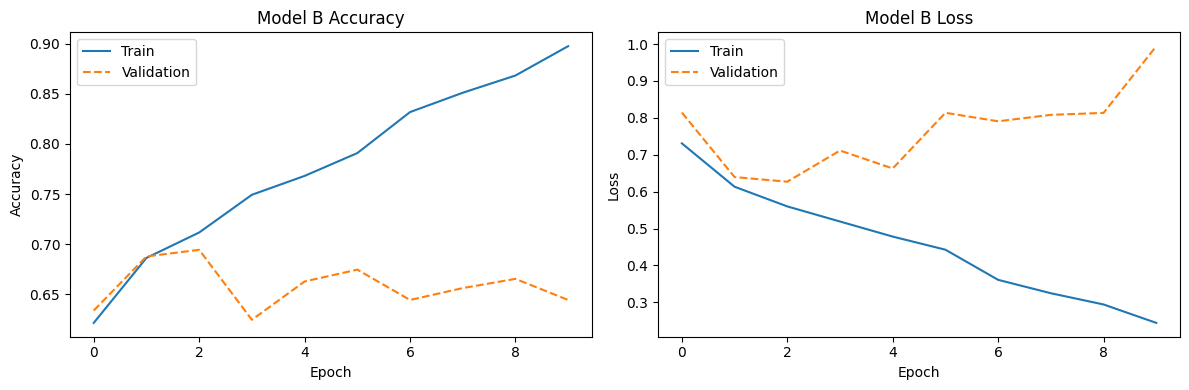

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


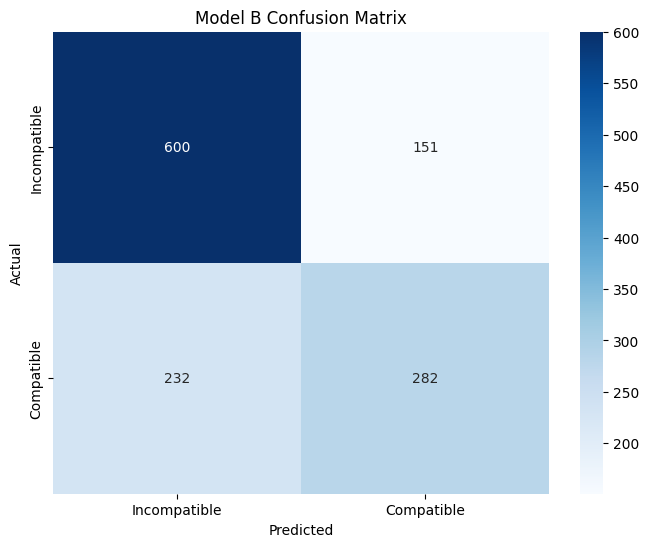

In [48]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], linestyle='--', label='Validation')
plt.title('Model B Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], linestyle='--', label='Validation')
plt.title('Model B Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Confusion Matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Incompatible', 'Compatible'],
    yticklabels=['Incompatible', 'Compatible']
)

plt.title('Model B Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#### Model A vs. Model B Comparison

In [49]:
# Model Accuracy Comparison
print("Final Model Comparison:")
print(f"Model A Accuracy: {avg_result[1] * 100:.2f}%")
print(f"Model B Accuracy: {result[1] * 100:.2f}%")

# Model Comparison Table
comparison_df = pd.DataFrame({
    "Model": [
        "Model A",
        "Model B"
    ],
    "Input Representation": [
        "Average of all item embeddings",
        "Item embeddings + average embedding"
    ],
    "Input Size": [
        X_avg.shape[1],
        X.shape[1]
    ],
    "Test Accuracy": [
        avg_result[1],
        result[1]
    ]
})

comparison_df.style.hide(axis="index")

Final Model Comparison:
Model A Accuracy: 61.66%
Model B Accuracy: 69.72%


Model,Input Representation,Input Size,Test Accuracy
Model A,Average of all item embeddings,2048,0.616601
Model B,Item embeddings + average embedding,10240,0.697233


#### Visualize Correct/Wrong Predictions

Actual Compatible, Predicted Compatible


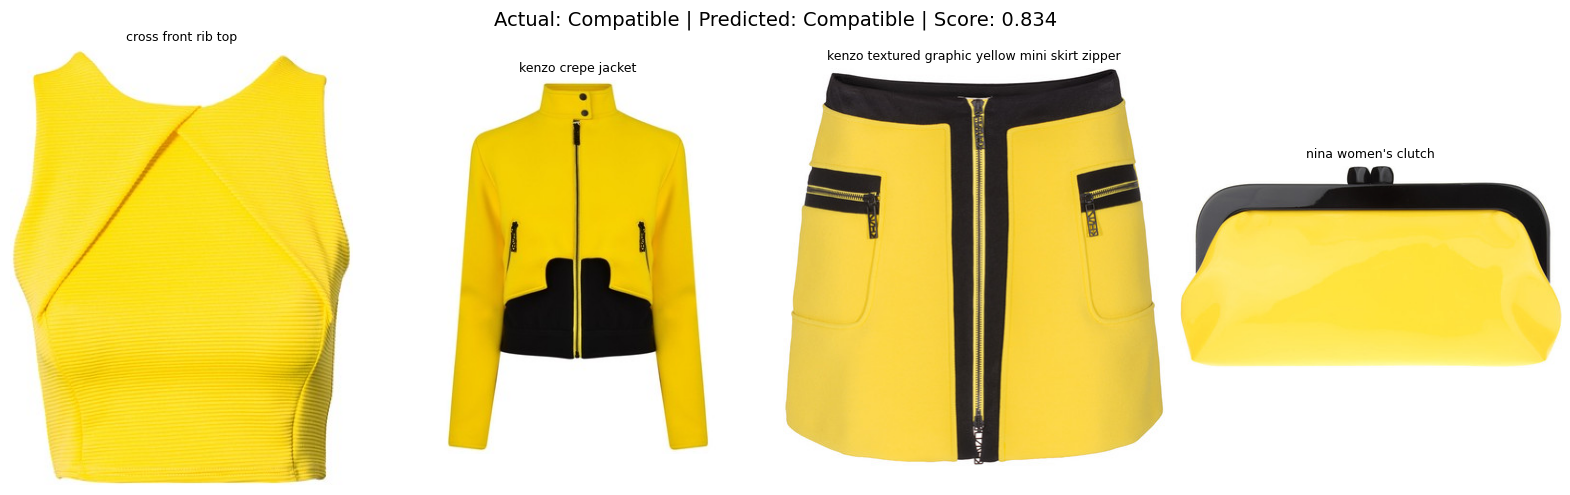

Actual Incompatible, Predicted Incompatible


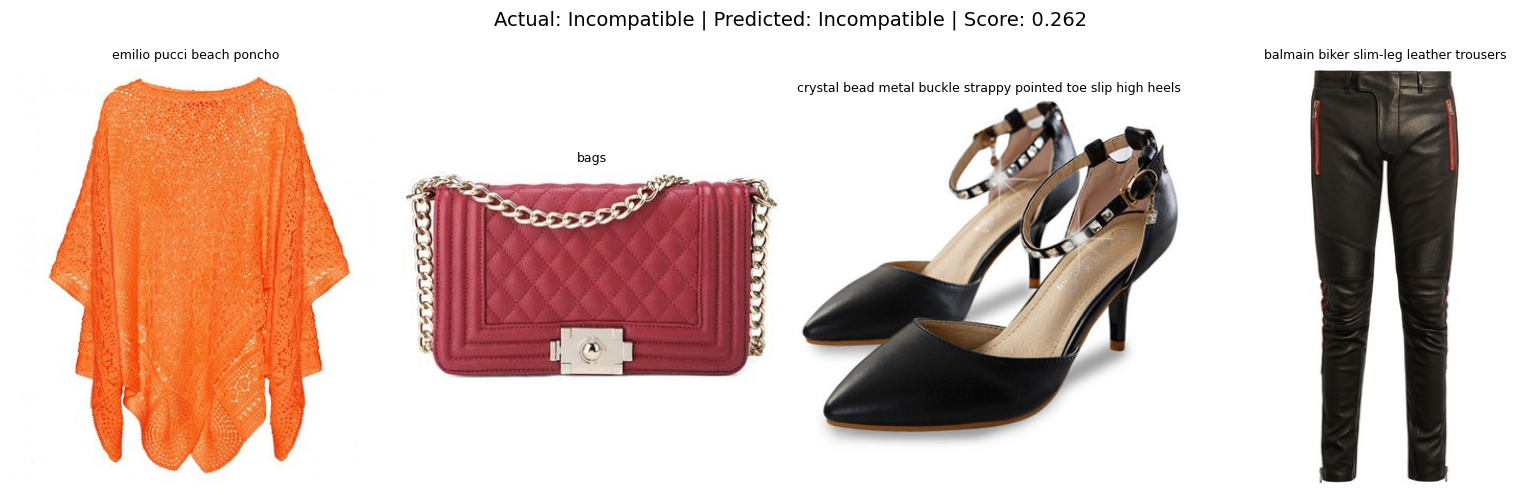

Actual Compatible, Predicted Incompatible


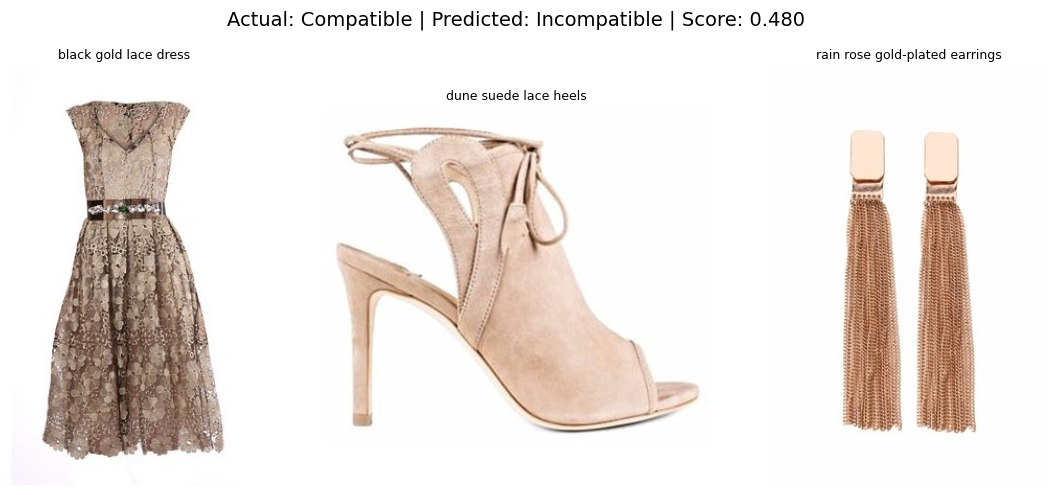

Actual Incompatible, Predicted Compatible


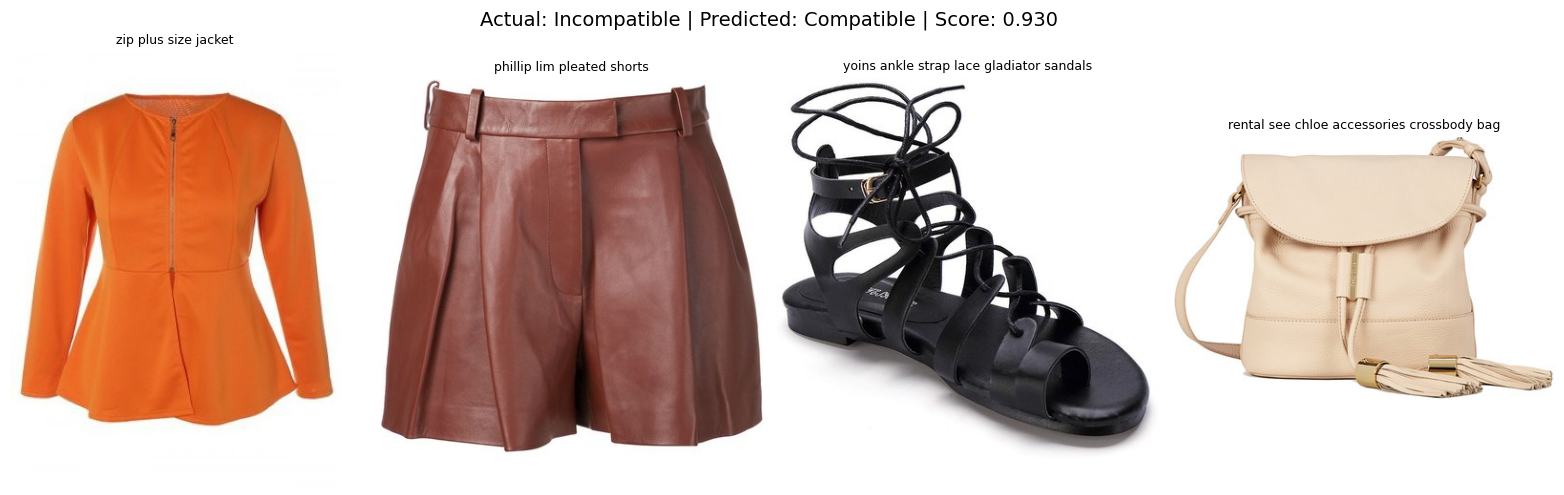

In [50]:
# Model B: Visualize Correct and Incorrect Prediction Examples

# Reconnect test predictions to the original outfit item IDs
outfit_item_ids = []
outfit_labels = []

for line in lines:
    parts = line.strip().split()

    if len(parts) < 2:
        continue

    label = int(parts[0])
    item_ids = parts[1:]

    if any(item_id in image_lookup for item_id in item_ids):
        outfit_item_ids.append(item_ids)
        outfit_labels.append(label)

outfit_item_ids = np.array(outfit_item_ids, dtype=object)
outfit_labels = np.array(outfit_labels)

_, item_ids_test, _, _ = train_test_split(
    outfit_item_ids,
    outfit_labels,
    test_size=0.2,
    random_state=42,
    stratify=outfit_labels
)

# Get predictions from the already-trained Model B
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob > 0.5).astype(int)


def show_prediction(index):
    """
    Displays one Model B prediction example from the test set.

    Parameters:
        index (int): Index of the outfit in the test set.

    Shows:
        The outfit's available item images, actual label, predicted label,
        and compatibility score.
    """
    item_ids = item_ids_test[index]
    actual = y_test[index]
    predicted = y_pred[index]
    score = y_prob[index]

    available_items = [item_id for item_id in item_ids if item_id in image_lookup][:4]

    actual_label = "Compatible" if actual == 1 else "Incompatible"
    predicted_label = "Compatible" if predicted == 1 else "Incompatible"

    _, axes = plt.subplots(1, len(available_items), figsize=(4 * len(available_items), 5))

    if len(available_items) == 1:
        axes = [axes]

    for ax, item_id in zip(axes, available_items):
        img = Image.open(image_lookup[item_id])
        ax.imshow(img)
        ax.set_title(name_lookup.get(item_id, item_id), fontsize=9, wrap=True)
        ax.axis("off")

    plt.suptitle(
        f"Actual: {actual_label} | Predicted: {predicted_label} | Score: {score:.3f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# Four prediction types
correct_compatible = np.where((y_test == 1) & (y_pred == 1))[0]
correct_incompatible = np.where((y_test == 0) & (y_pred == 0))[0]
false_negative = np.where((y_test == 1) & (y_pred == 0))[0]
false_positive = np.where((y_test == 0) & (y_pred == 1))[0]


# Display one example from each type with at least 3 available images

print("Actual Compatible, Predicted Compatible")
for index in correct_compatible:
    if len([item_id for item_id in item_ids_test[index] if item_id in image_lookup]) >= 3:
        show_prediction(index)
        break

print("Actual Incompatible, Predicted Incompatible")
for index in correct_incompatible:
    if len([item_id for item_id in item_ids_test[index] if item_id in image_lookup]) >= 3:
        show_prediction(index)
        break

print("Actual Compatible, Predicted Incompatible")
for index in false_negative:
    if len([item_id for item_id in item_ids_test[index] if item_id in image_lookup]) >= 3:
        show_prediction(index)
        break

print("Actual Incompatible, Predicted Compatible")
for index in false_positive:
    if len([item_id for item_id in item_ids_test[index] if item_id in image_lookup]) >= 3:
        show_prediction(index)
        break

## Test Your Own Outfit! - Human Parsing & Compatibility Prediction

In [51]:
# Install if needed:
# %pip install transformers timm --quiet

from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

# ── ATR label map (17 classes) ──────────────────────────────────────────────
# Trained on the ATR dataset; these are the standard label IDs.
ATR_LABELS = {
    0:  "background",
    1:  "hat",
    2:  "hair",
    3:  "sunglasses",
    4:  "top",          # upper-body clothing (shirt, blouse, jacket…)
    5:  "skirt",
    6:  "pants",
    7:  "dress",
    8:  "belt",
    9:  "left_shoe",
    10: "right_shoe",
    11: "face",
    12: "left_leg",
    13: "right_leg",
    14: "left_arm",
    15: "right_arm",
    16: "bag",
}

# Logical clothing groups we care about downstream
CATEGORY_GROUPS = {
    "top":    {4},            # shirt / jacket / blouse
    "bottom": {5, 6},         # skirt or pants
    "dress":  {7},            # full-body; replaces top + bottom
    "shoes":  {9, 10},        # left + right merged
}

# Load SegFormer fine-tuned on ATR (human parsing)
PARSER_MODEL = "mattmdjaga/segformer_b2_clothes"

print("Loading human parsing model…")
processor = SegformerImageProcessor.from_pretrained(PARSER_MODEL)
parser    = SegformerForSemanticSegmentation.from_pretrained(PARSER_MODEL)
parser.eval()
print("Model ready.")


def parse_clothing(pil_image):
    """
    Run human parsing on a PIL image.

    Returns
    -------
    label_map : np.ndarray  shape (H, W), dtype int
        Per-pixel ATR label ID (same spatial size as the input image).
    """
    inputs = processor(images=pil_image, return_tensors="pt")
    with torch.no_grad():
        logits = parser(**inputs).logits          # (1, num_labels, H/4, W/4)

    # Upsample back to original image size
    H, W = pil_image.height, pil_image.width
    upsampled = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
    label_map  = upsampled.argmax(dim=1).squeeze(0).numpy().astype(np.int32)
    return label_map


def visualise_parse(pil_image, label_map):
    """Overlay colour-coded segments on the original image (for debugging)."""
    colours = {
        4: (255, 100,  50),   # top    — orange
        5: ( 50, 150, 255),   # skirt  — blue
        6: ( 50, 150, 255),   # pants  — blue
        7: (150,  50, 255),   # dress  — purple
        9: ( 50, 200,  50),   # l shoe — green
       10: ( 50, 200,  50),   # r shoe — green
    }
    overlay = np.array(pil_image.convert("RGB"), dtype=np.float32)
    for label_id, colour in colours.items():
        mask = (label_map == label_id)
        for c, v in enumerate(colour):
            overlay[mask, c] = overlay[mask, c] * 0.4 + v * 0.6
    return Image.fromarray(overlay.astype(np.uint8))

def extract_clothing_crops(pil_image, label_map, apply_mask=False, padding=10):
    """
    Crop individual clothing regions from a parsed image.

    Parameters
    ----------
    pil_image  : PIL.Image   The original RGB image.
    label_map  : np.ndarray  Per-pixel ATR label IDs (H, W).
    apply_mask : bool        If True, black-out pixels outside the segment mask.
    padding    : int         Extra pixels to add around each bounding box.

    Returns
    -------
    crops : dict  {category_name: PIL.Image}
        One cropped PIL image per detected clothing category.
    """
    img_arr = np.array(pil_image.convert("RGB"))
    H, W = label_map.shape
    crops = {}

    for category, label_ids in CATEGORY_GROUPS.items():
        # Build a combined mask for all label IDs in this group
        mask = np.zeros((H, W), dtype=bool)
        for lid in label_ids:
            mask |= (label_map == lid)

        if not mask.any():
            continue  # this category not present in the photo

        # Bounding box of the masked region
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        y0 = max(rows[0]  - padding, 0)
        y1 = min(rows[-1] + padding, H - 1)
        x0 = max(cols[0]  - padding, 0)
        x1 = min(cols[-1] + padding, W - 1)

        crop = img_arr[y0:y1+1, x0:x1+1].copy()

        if apply_mask:
            # Zero-out background pixels within the crop
            crop_mask = mask[y0:y1+1, x0:x1+1]
            crop[~crop_mask] = 0

        crops[category] = Image.fromarray(crop)

    return crops


Loading human parsing model…


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Model ready.


In [52]:
def get_embedding_from_pil(pil_img):
    """
    Same as get_embedding() but accepts a PIL image directly
    instead of an item_id / file path.
    """
    img  = pil_img.resize((224, 224))
    arr  = keras_image.img_to_array(img)
    arr  = np.expand_dims(arr, axis=0)
    arr  = preprocess_input(arr)
    return base_model.predict(arr, verbose=0)[0]


def get_outfit_embedding_from_photo(image_path, apply_mask=False):
    """
    Full Phase 1→2→3 pipeline for a single photo of a person.

    1. Parse clothing regions  (Phase 1)
    2. Crop each clothing item (Phase 2)
    3. Extract ResNet50 feature vector per crop (Phase 3)
    4. Combine into a fixed-size outfit embedding (Phase 4 logic)

    Returns
    -------
    embedding : np.ndarray  shape (max_items*2048 + 2048,)
        Ready to pass into the compatibility classifier.
    crops     : dict  {category: PIL.Image}  — for inspection
    """
    MAX_ITEMS = 4

    pil_img   = Image.open(image_path).convert("RGB")
    label_map = parse_clothing(pil_img)
    crops     = extract_clothing_crops(pil_img, label_map, apply_mask=apply_mask)

    embeddings = [get_embedding_from_pil(crop) for crop in crops.values()]

    if not embeddings:
        raise ValueError(f"No clothing detected in {image_path}")

    dim      = embeddings[0].shape[0]
    mean_emb = np.mean(embeddings, axis=0)

    # Pad to max_items (same strategy as get_outfit_embedding)
    padded = embeddings[:MAX_ITEMS]
    while len(padded) < MAX_ITEMS:
        padded.append(np.zeros(dim))

    combined = np.concatenate(padded + [mean_emb])
    return combined, crops





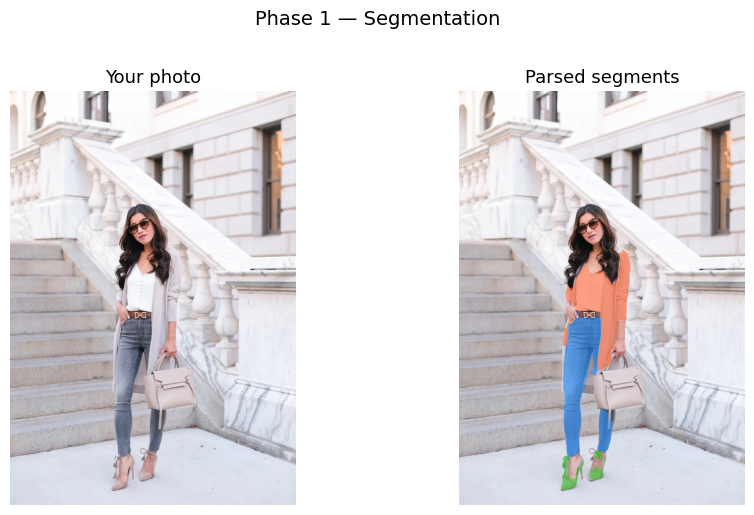

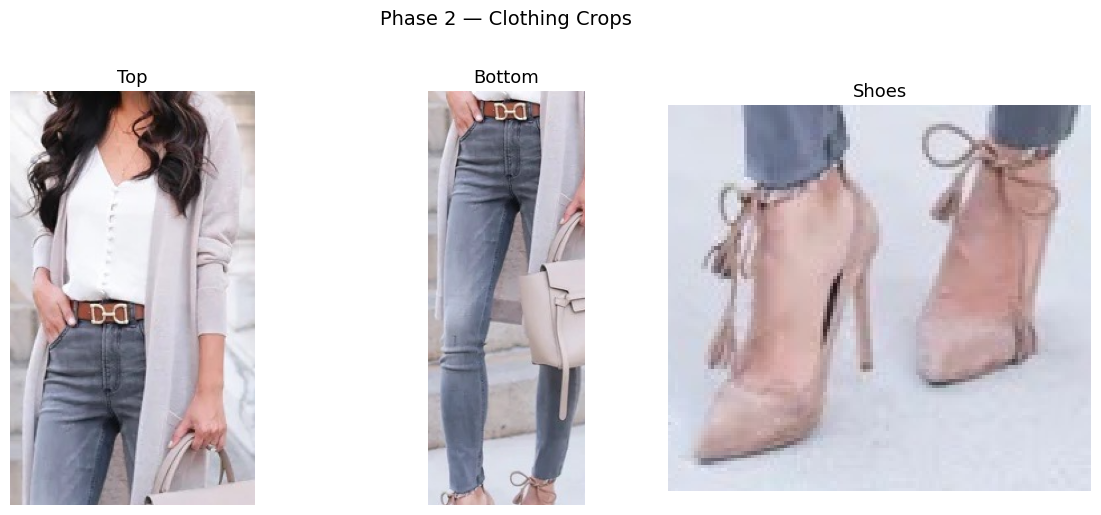

Detected: ['top', 'bottom', 'shoes']

Compatibility score : 0.644
Verdict             : Compatible


In [53]:
def test_my_outfit(image_path, apply_mask=False):
    """
    Point this at any photo of yourself and it will:
      1. Parse clothing regions
      2. Show the segmentation overlay
      3. Crop each detected item (top, bottom, shoes, dress)
      4. Print the compatibility score if the classifier is loaded

    Parameters
    ----------
    image_path  : str   path to your photo, e.g. 'my_outfit.jpg'
    apply_mask  : bool  True = black-out background in each crop
    """
    pil_img   = Image.open(image_path).convert("RGB")
    label_map = parse_clothing(pil_img)
    crops     = extract_clothing_crops(pil_img, label_map, apply_mask=apply_mask)

    if not crops:
        print("No clothing detected — try a clearer full-body photo.")
        return

    # ── Row 1: original + segmentation overlay ──────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(pil_img)
    axes[0].set_title("Your photo", fontsize=13)
    axes[0].axis("off")
    axes[1].imshow(visualise_parse(pil_img, label_map))
    axes[1].set_title("Parsed segments", fontsize=13)
    axes[1].axis("off")
    plt.suptitle("Phase 1 — Segmentation", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # ── Row 2: individual crops ──────────────────────────────────────────────
    n = len(crops)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (cat, crop_img) in zip(axes, crops.items()):
        ax.imshow(crop_img)
        ax.set_title(cat.capitalize(), fontsize=13)
        ax.axis("off")
    plt.suptitle("Phase 2 — Clothing Crops", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Detected: {list(crops.keys())}")

    # ── Optional: compatibility score ────────────────────────────────────────
    try:
        embedding, _ = get_outfit_embedding_from_photo(image_path, apply_mask=apply_mask)
        score = model.predict(embedding[np.newaxis], verbose=0)[0][0]
        label = "Compatible" if score > 0.5 else "Incompatible"
        print(f"\nCompatibility score : {score:.3f}")
        print(f"Verdict             : {label}")
    except Exception as e:
        print(f"\n(Classifier not available yet: {e})")


# ── Usage ────────────────────────────────────────────────────────────────────
# Drop your photo into the same folder as this notebook, then run:

test_my_outfit("my_outfit.jpeg")

# To black-out the background in each crop:
# test_my_outfit("my_outfit.jpg", apply_mask=True)
